<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/0930_private_rag_bikeseoul_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 로컬 RAG 만들고 개선하기

- **트랙 1 — 인덱싱 처리량과 배치 최적화:** 제한된 GPU 메모리에서 배치 크기와 정밀도를 조절해 처리 속도를 높이고 싶었다.
- **트랙 2 — 하이브리드 검색:** 의미가 비슷한 질문과 ‘365일권’ 같은 정확한 식별자가 포함된 질문을 함께 처리하고 싶었다.
- **트랙 4 — 부모–자식 청킹:** 작은 문장으로 검색하면서 답변에는 관련 조건과 예외까지 전달하는 효과를 확인하고 싶었다.


- 기준선: 구조 기반 청킹 → BGE-M3 → Qdrant → Qwen.



## Step 0. 환경 준비


In [1]:
%pip install -q "langchain-huggingface==0.3.*" "langchain-text-splitters==0.3.*" "sentence-transformers==5.7.*" "qdrant-client==1.12.*" "transformers==4.57.*" "accelerate==1.14.*" "bitsandbytes==0.50.*" "rank_bm25==0.2.2" pandas matplotlib tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.2/267.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 31.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

In [2]:
import os
import torch
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 전체 재실행 전에 이전 오프라인 설정을 해제한다.
os.environ.pop("HF_HUB_OFFLINE", None)
os.environ.pop("TRANSFORMERS_OFFLINE", None)

if not torch.cuda.is_available():
    raise RuntimeError("Colab에서 GPU 런타임을 선택한 뒤 다시 실행하세요.")

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
os.makedirs("bikeseoul_rag_results", exist_ok=True)

GPU : Tesla T4
VRAM : 15.6 GB


## Step 1. 문서 준비
출처: [서울시설공단 공공자전거 안내](https://sisul.or.kr/open_content/traffic/bikeseoul.jsp), 확인일 2026-09-30.
이용방법·요금표·안전수칙의 사실을 한국어로 정리했다. 표는 문장으로 바꾸고 중복·홍보 문구와 통계는 제외했다.
세부 제목은 실습용이며 공식 조항 번호가 아니다. 원문에 없는 요금이나 규정은 추가하지 않았다.
아래 셀은 예제의 `%%writefile` 방식으로 문서를 만든다.

In [3]:
%%writefile bikeseoul_guide.md
%%writefile bikeseoul_guide.md
# 서울공공자전거 따릉이 이용약관 발췌

## 이용약관 · 2026년 9월 1일 시행

### 제5조 (회원신청)

① 자전거 운전이 가능한 13세 이상의 국민은 누구나 서울공공자전거의 회원이 될 수 있습니다.

② 서울공공자전거의 회원이 되기를 원하는 경우, 서울공공자전거 앱에서 회원에 가입하여야 합니다.

③ 회원가입 시 회원은 다음 각 호의 필수 기재사항을 기입하여야 합니다. 반드시 본인의 정보를 기입하여야 하며, 변경사항 발생 시 지체없이 갱신하여야 합니다. 허위 사항 기재 또는 미갱신 시 불이익을 받을 수 있습니다.
(단, 간편로그인은 간편로그인 절차에 따릅니다.)

1. 생년

2. 휴대전화번호

3. 아이디 ‧ 비밀번호

④ 13세의 경우 회원가입 시 「개인정보 보호법」 제22조의 2에 따라 개인정보의 처리에 관하여 법정대리인의 동의를 받아야 하며, 동의 확인에 필요한 사항은 별도의 개인정보처리방침에 따릅니다.

### 제9조 서비스 이용 시 주의사항

① 이용자는 서울자전거가 제공하는 서비스를 통하여 자전거에 대한 이용요금을 지불하고 자전거를 이용해야 합니다.

② 이용자는 서비스를 통하여 자전거를 이용함에 있어서는 본 약관에 규정된 내용은 물론 「도로교통법」, 「자전거 이용 활성화에 관한 법률」 및 이와 관련된 각 시행령, 시행규칙, 각 지방자치단체마다 개별적으로 규정된 자전거 이용 활성화에 관한 조례 등 일체의 관련 법령 및 자치 법규에 규정된 내용을 모두 준수 하여야 합니다.

③ 서비스 이용 시 고의 내지 과실로 인하여 본조 제2항에 규정된 본 약관 내용 및 관련 법령, 자치법규를 위반하는 회원은 본 약관상 규정된 불이익 내지 관련 법령 및 자치법규상 규정된 불이익을 받게 되며, 서울공공자전거에서는 이에 대하여 어떠한 책임도 부담하지 않습니다.

④ 다음 각 호 어느 하나에 해당하는 경우를 제외하고는 13세 이하인 자는 따릉이를 이용할 수 없습니다.

1. 「개인정보 보호법」 제22조의 2에 따라 개인정보의 처리에 관하여 법정대리인의 동의를 받고 회원가입을 마친 13세 아동이 대여하는 경우

2. 가족권으로 이용하는 경우

### 제10조 서비스 이용시간

① 서울공공자전거 1시간제 이용권의 대여 1회당 기본 이용시간은 60분으로, 회당 60분 이내 반납시 반복대여가 가능하며 일일권 기준 대여 개시부터 24시간까지 이용할 수 있습니다. 1회 이용 시 60분 이용시간을 초과할 경우 서울공공자전거가 지정한 추가요금 납부를 원칙으로 합니다.

② 서울공공자전거 2시간제 이용권의 대여 1회당 기본 이용시간은 120분으로, 회당 120분 이내 반납시 반복대여가 가능하며 일일권 기준 대여 개시부터 24시간까지 이용할 수 있습니다. 1회 이용시 120분 이용시간을 초과할 경우 서울공공자전거가 지정한 추가요금 납부를 원칙으로 합니다.

③ 서울공공자전거 3시간제 이용권의 대여 1회당 기본 이용시간은 180분으로, 회당 180분 이내 반납시 반복대여가 가능하며 일일권 기준 대여 개시부터 24시간까지 이용할 수 있습니다. 1회 이용시 180분 이용시간을 초과할 경우 서울공공자전거가 지정한 추가요금 납부를 원칙으로 합니다.

④ 최대 초과 대여시간 안에 반납되지 않을 시 분실(도난)로 간주하여 분실(도난) 신고할 수 있습니다.

### 제11조 서비스 이용요금

① 서울공공자전거의 서비스 이용은 유료이며, 서울공공자전거에서 정한 이용요금을 징수합니다.

② 서울공공자전거는 서비스에 적용되는 이용요금‧추가요금‧환불정보를 홈페이지‧앱 이용정책 등을 통하여 회원에게 공지합니다.

③ 경우에 따라 이용요금 산정 기준은 변경될 수 있으며, 이에 대한 서울공공자전거의 적절한 공지 및 안내에도 불구하고 회원이 이를 숙지하지 못하여 입게 되는 손해에 대하여 서울공공자전거는 어떠한 책임도 부담하지 않습니다.

④ 기본 이용시간을 초과할 경우, 이용권 구매 시 사용된 결제수단 또는 사용자가 사전에 지정한 결제수단을 통하여 추가요금이 청구됩니다.

⑤ 서울공공자전거 이용 도중 이용자 자신의 위반행위(서울공공자전거 서비스 이용약관 위반)로 인하여 부과 받은 벌금‧추가요금은 이용자 본인이 직접 부담하여야 합니다.

### 제12조 회원자격 정지·해지 및 서비스 이용제한

① 서울공공자전거는 아래의 각 호에 해당하는 경우, 회원자격을 정지, 해지할 수 있으며, 이 경우 비회원 서비스 이용도 제한됩니다.

1. 본 약관 제6조 제2항 각 호에 따라 명시된 회원가입 거부사유에 해당하는 사실이 추후 확인된 경우

2. 본 약관 제16조 등에 명시된 이용자의 의무와 책임관련 내용을 준수하지 않는 경우

3. 기타 본 약관 및 관련 법령에 위반되거나, 사회질서에 반하는 행위를 하여 회원자격을 유지하는 것이 부적절하다고 판단되는 경우

② 제1항과는 별도로 아래의 각 호 위반 행위에 대해서는 명시된 기간 동안 서비스 이용이 제한됩니다.

1. 본 약관 제16조 제7항 제17호 위반으로 혈중알코올농도 0.03%이상의 술에 취한 상태(「도로교통법」제44조 제4항)에서 서울공공자전거를 이용한 경우 : 1년

2. 누구든지 고의로 서울공공자전거 시설물을 훼손한 경우 : 1회 위반 6개월, 2회 위반 1년

③ 회원이 본인의 회원자격을 정지 또는 해지(탈퇴)하고자 할 경우, 서울공공자전거 홈페이지나 앱, 서울공공자전거(“따릉이”) 콜센터에 연락하여 회원자격에 대한 정지 및 해지 신청을 하여야 합니다.

④ 서울공공자전거는 회원자격 정지·해지 또는 탈퇴처리 시, 서울공공자전거에서 지정한 공제금액을 제외한 기본요금을 환불 처리합니다. 잔여 이용권이 존재하는 회원의 경우 환불 및 연장 규정에 따라 환불 처리 합니다.

⑤ 제1항과 제2항에 따른 서비스 이용정지 및 기타 서비스 이용과 관련된 이용제한에 대해 서울공공자전거가 정한 절차에 따라 이의신청을 할 수 있으며, 서울공공자전거가 회원의 이의신청이 정당하다고 판단되는 경우 즉시 서비스 이용을 재개합니다.

⑥ 서울공공자전거 서비스와 관련하여 발생한 미납 경비, 손해배상채무 등 회원의 서울공공자전거에 대한 채무가 전부 정산될 때까지 해당 회원의 서비스 사용은 중지되며, 해당 회원이 그 채무를 상당 기간 계속하여 변제하지 않을 경우에는 서울공공자전거는 해당 회원의 회원자격을 박탈할 수 있습니다. 또한 서비스 사용중지 또는 회원자격 박탈에 대한 판단 기준은 서울공공자전거의 본 약관 및 이용정책에 근거합니다.

⑦ 회원이 사망한 경우 회원 사망일에 회원자격이 상실되며, 제3자가 사망자의 회원자격을 도용하여 행한 모든 행위는 유효한 것으로 인정되지 않습니다.

⑧ 회원 탈퇴 시 회원이 보유한 이용권은 자동으로 소멸됩니다.

### 제13조 기본요금 환불 및 결제 취소

① 환불 처리 시 소요되는 결제 수수료 등의 비용은 회원이 원하여 탈퇴할 경우 회원이, 서울공공자전거 서비스 하자로 인한 경우에는 서울공공자전거에서 부담합니다.

② 이용권의 대여 개시 유효기간은 결제일로부터 1년(365일)으로 정합니다. 대여 개시하지 않은 상태로 유효기간 초과 시 자전거 대여가 불가능하며, 해당 이용권에 대하여 전액 자동 결제취소 또는 전액 계좌이체 환불 처리합니다.

③ 기본요금의 환불은 서비스를 이용하지 않은 경우 해당 이용권에 대한 결제 취소 방식으로(단, 미사용권 중 과월 휴대폰 소액결제 건은 계좌번호로 환불), 서비스를 이용 중인 경우 서울공공자전거 환불정책에 따른 정산금액을 회원의 최초 결제수단과 동일한 수단으로 환불하는 방식을 사용합니다. 환불정책은 서울공공자전거 홈페이지에 별도 게재합니다.

### 제14조 추가요금

① 기본 이용시간 초과 시 5분마다 200원씩 추가 요금이 이용자에게 부과됩니다.

② 추가요금은 1회 대여 시 최대 30,000원까지 부과 됩니다.

③ 이용자 본인의 과실로 인한 자전거 대여‧반납 서비스에 따른 추가 요금 발생 시 전액 이용자가 부담합니다.

### 제16조 이용자의 의무와 책임 — 제10항 제11호 발췌

⑩ 이용자는 서울공공자전거를 이용할 때 다음 각 호의 의무사항과 책임을 준수하여야 합니다.

11. 가족권 이용자가 13세 미만인 경우 이용자의 보호자는 다음 각 목의 사항을 모두 이행해야 합니다.

가. 「도로교통법」 제11조 제3항에 의거하여 이용자가 인명보호 장구(안전모)를 착용하게 해야 합니다.

나. 사전에 따릉이의 규격이 이용자의 신체 조건에 적합한지 확인해야 합니다.

다. 사전에 따릉이의 핸들·브레이크·타이어·체인 등 부품의 이상 유무를 점검해야 합니다.

라. 이용자 혼자 또는 이용자들끼리 따릉이를 대여하거나 운전하지 않도록 지도·감독해야 합니다.

마. 「도로교통법」 제13조의2에 따라 이용자가 보도, 자전거도로, (자전거도로가 없는 경우) 도로 우측 가장자리에서 통행하도록 지도해야 합니다.

### 제18조 이의신청 및 손해배상

① 이용자의 실수 및 부주의로 인해 발생한 문제에 대해서는 서울공공자전거 관계 기관과 위탁 운영기관은 책임을 지지 아니합니다. 단, 공단 귀책사항에 의한 서울공공자전거 이용 불가로 발생한 손해의 경우, 보상은 장애로 인한 미사용 기간에 대한 연장에 한하며, 보상기준은 서울공공자전거 홈페이지에 게시한 환불정책에 따릅니다.

② 태풍, 우천, 폭설 등의 기상상태 악화 등 비정상적인 상황, 또는 상기 비상 상황에 대비(복구)하기 위하여 서비스 제공이 불가능할 경우, 이로 인해 회원에게 발생한 손해에 대하여 책임을 부담하지 않습니다.

③ 이용자가 서울공공자전거에서 제공되는 자전거 이용 중 자전거의 결함으로 인하여 사고를 당하였을 경우 서울공공자전거에서 가입한 ‘영조물 손해배상 보험’ 약관에 의하여 배상을 받을 수 있으며, 그 외 서울공공자전거 이용 중에 발생하는 사고에 대하여는 ‘서울공공자전거 종합보험’ 약관에 의하여 배상을 받을 수 있습니다. 단, 다음 각 호 어느 하나에 해당하는 경우 배상받을 수 없습니다.

1. 본 약관 제9조 제4항을 위반한 경우

2. 15세 미만 이용자의 사망 사고를 사유로 사망보험금을 청구하는 경우

※ 자세한 사항은 서울공공자전거 홈페이지 → 보험안내 참조

※ 단, 공공자전거 결함 및 관리상 하자의 입증 책임은 이용자 본인에게 있으므로, 사고가 발생할 경우 반드시 이용자 본인이 증빙자료를 수집하여 영조물 손해배상 접수 시 제출하여야 합니다.

※ 증빙자료 : 사고 직후 촬영한 자전거 사진 또는 동영상, 인적·물적 피해를 증명할 수 있는 사진 등

Writing bikeseoul_guide.md


In [4]:
with open("bikeseoul_guide.md", encoding="utf-8") as f:
    document = f.read()

print(f"문서 길이 : {len(document)}자")

문서 길이 : 5129자


## Step 2. 구조 기반 청킹과 평가 질문
예제의 `MarkdownHeaderTextSplitter`를 사용한다. `##`는 분류, `###`는 이용권·절차·수칙별 항목이다.
부모는 각 항목 전체로 만들어 요금과 시간의 관계, 조건과 예외를 함께 보존한다.
큰 청크 3개만 만들면 Hit@3가 의미 없어지므로 항목별로 나눈다.

평가 세트는 예제와 같은 `(질문, 정답 청크 번호)` 형식이다. 질문과 정답은 실행 전에 고정한다.
이 질문 세트는 설정 비교용이며 별도 시험 세트에서 검증한 일반화 성능은 아니다.

In [17]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [
    ("#", "문서"),
    ("##", "분류"),
    ("###", "항목"),
]

md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
md_chunks = md_splitter.split_text(document)

print(f"청크 수 : {len(md_chunks)}")

# 청크 목록을 번호와 함께 확인합니다
chunks = md_chunks

for i, c in enumerate(chunks):
    print(f"[{i}] {c.metadata.get('항목', c.metadata.get('분류', ''))}")

청크 수 : 10
[0] 
[1] 제5조 (회원신청)
[2] 제9조 서비스 이용 시 주의사항
[3] 제10조 서비스 이용시간
[4] 제11조 서비스 이용요금
[5] 제12조 회원자격 정지·해지 및 서비스 이용제한
[6] 제13조 기본요금 환불 및 결제 취소
[7] 제14조 추가요금
[8] 제16조 이용자의 의무와 책임 — 제10항 제11호 발췌
[9] 제18조 이의신청 및 손해배상


In [20]:
import re

article_idx = {}

for i, c in enumerate(chunks):
    # '항목'이 없는 청크에도 이후 출력에 사용할 제목 부여
    title = (
        c.metadata.get("항목")
        or c.metadata.get("분류")
        or c.metadata.get("문서")
        or "본문"
    )
    c.metadata["항목"] = title

    # '제5조', '제 5 조' 형태의 제목에서 조항 번호 추출
    match = re.match(r"제\s*(\d+)\s*조", title)
    if match:
        article_idx[int(match.group(1))] = i

    print(f"[{i}] {title}")

# 평가 질문에 필요한 조항이 실제로 존재하는지 확인
required = {5, 9, 10, 11, 12, 13, 14, 16, 18}
missing = required - article_idx.keys()

assert not missing, (
    f"찾지 못한 조항: {sorted(missing)}. "
    "새 문서를 다시 읽고 청킹했는지, "
    "조항 제목이 '### 제5조 ...' 형식인지 확인하세요."
)

print("조항 → 청크 번호:", article_idx)

# 의미 질문 10개
eval_set = [
    ("가입할 때 입력한 정보가 바뀌면 어떻게 해야 해?", article_idx[5]),
    ("열세 살 이하인 아이가 이용할 수 있는 예외는 뭐야?", article_idx[9]),
    ("반납하고 다시 빌리는 식으로 하루 동안 여러 번 이용할 수 있어?", article_idx[10]),
    ("이용 시간을 넘기면 어떤 결제수단으로 추가요금이 청구돼?", article_idx[11]),
    ("고의로 시설물을 두 번 훼손하면 얼마나 이용이 제한돼?", article_idx[12]),
    ("한 번도 쓰지 않은 이용권이 결제 후 일 년이 지나면 어떻게 처리돼?", article_idx[13]),
    ("내가 원해서 탈퇴하며 환불받을 때 결제 수수료는 누가 내?", article_idx[13]),
    ("시간을 초과했을 때 추가요금은 얼마씩 붙고 최대 얼마까지 내?", article_idx[14]),
    ("가족권으로 어린아이가 탈 때 보호자가 미리 확인해야 할 사항은?", article_idx[16]),
    ("자전거 결함으로 사고가 나면 증빙자료는 누가 모아야 해?", article_idx[18]),
]

# 식별자 질문 10개
id_eval_set = [
    ("제5조 제3항의 회원가입 필수 기재사항은?", article_idx[5]),
    ("제9조 제4항에서 정한 13세 이하 이용 예외 두 가지는?", article_idx[9]),
    ("제10조 제2항에 따른 2시간제의 회당 기본 이용시간은?", article_idx[10]),
    ("제10조 제3항에 따른 3시간제 일일권은 대여 개시부터 언제까지 이용해?", article_idx[10]),
    ("제11조 제4항에서 추가요금을 청구하는 결제수단은?", article_idx[11]),
    ("제12조 제2항에서 혈중알코올농도 0.03% 이상일 때 이용제한 기간은?", article_idx[12]),
    ("제13조 제2항에서 정한 이용권의 대여 개시 유효기간은?", article_idx[13]),
    ("제14조에 명시된 5분당 추가요금과 1회 대여 최대 추가요금은?", article_idx[14]),
    ("제16조 제10항 제11호에서 사전 점검하도록 한 자전거 부품은?", article_idx[16]),
    ("제18조 제3항에서 15세 미만 이용자의 사망보험금 청구는 어떻게 규정해?", article_idx[18]),
]

combined_eval = eval_set + id_eval_set

assert all(0 <= gold < len(chunks) for _, gold in combined_eval)
print(f"청크 {len(chunks)}개 / 평가 질문 {len(combined_eval)}개")

[0] 본문
[1] 제5조 (회원신청)
[2] 제9조 서비스 이용 시 주의사항
[3] 제10조 서비스 이용시간
[4] 제11조 서비스 이용요금
[5] 제12조 회원자격 정지·해지 및 서비스 이용제한
[6] 제13조 기본요금 환불 및 결제 취소
[7] 제14조 추가요금
[8] 제16조 이용자의 의무와 책임 — 제10항 제11호 발췌
[9] 제18조 이의신청 및 손해배상
조항 → 청크 번호: {5: 1, 9: 2, 10: 3, 11: 4, 12: 5, 13: 6, 14: 7, 16: 8, 18: 9}
청크 10개 / 평가 질문 20개


## Step 3. 로컬 임베딩
예제의 `HuggingFaceEmbeddings`와 `bge_embeddings`를 사용한다.
식별자 검색을 위해 제목과 본문을 함께 임베딩한다. 기준선·BM25·하이브리드 모두 같은 텍스트를 사용한다.

In [21]:
from langchain_huggingface import HuggingFaceEmbeddings

# 같은 셀을 다시 실행할 때 모델이 중복으로 올라가지 않게 한다.

if "bge_embeddings" not in globals():
    bge_embeddings = HuggingFaceEmbeddings(
        model_name="BAAI/bge-m3",
        model_kwargs={"device": "cuda"},
        encode_kwargs={"normalize_embeddings": True},   # 코사인 유사도 계산을 위한 정규화
    )

In [22]:
chunk_texts = [
    f"{c.metadata.get('분류', '')} {c.metadata.get('항목', '')}\n{c.page_content}"
    for c in chunks
]
bge_doc_vecs = np.array(bge_embeddings.embed_documents(chunk_texts))
print(f"BGE-M3 문서 벡터 : {bge_doc_vecs.shape}")

BGE-M3 문서 벡터 : (10, 1024)


## Step 4. Qdrant와 기준선 검색
예제처럼 벡터와 메타데이터를 저장하고 `retrieve()`로 검색한다.
작은 실습 데이터는 메모리 모드를 사용한다. 셀 재실행 시 이 실습 인덱스를 다시 만들고,
이전 `qdrant_local` 폴더와 잠금을 공유하지 않는다.

In [23]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

if "client" in globals():
    client.close()
client = QdrantClient(location=":memory:")


# 컬렉션 생성. 관계형 DB의 테이블에 해당합니다
# 벡터 차원 수와 거리 계산 방식을 지정해야 합니다

COLLECTION = "bikeseoul"

# 재실행에 대비해, 이미 있으면 지우고 새로 만듭니다
# (recreate_collection은 폐기 예정 API라 쓰지 않습니다)
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)

client.create_collection(
    collection_name=COLLECTION,
    vectors_config=VectorParams(
        size=1024,                  # BGE-M3의 차원 수. Step 3에서 확인한 값입니다
        distance=Distance.COSINE,
    ),
)

from qdrant_client.models import PointStruct

# 벡터와 함께 payload(메타데이터)를 저장합니다
# Step 2의 구조 기반 청킹이 만들어준 항목 정보가 여기서 쓰입니다

points = [
    PointStruct(
        id=i,
        vector=bge_doc_vecs[i].tolist(),
        payload={
            "text": chunks[i].page_content,
            "분류": chunks[i].metadata.get("분류", ""),
            "항목": chunks[i].metadata.get("항목", ""),
        },
    )
    for i in range(len(chunks))
]

client.upsert(collection_name=COLLECTION, points=points)
print(f"{len(points)}개 포인트 저장 완료")

10개 포인트 저장 완료


In [24]:
def retrieve(query: str, top_k: int = 3) -> list:
    """로컬 임베딩 + 로컬 Qdrant 검색"""
    query_vec = bge_embeddings.embed_query(query)
    results = client.query_points(
        collection_name=COLLECTION,
        query=query_vec,
        limit=top_k,
    ).points
    return [
        {"청크번호": r.id, "항목": r.payload["항목"], "내용": r.payload["text"], "유사도": r.score}
        for r in results
    ]

def dense_rank(query, top_n=10):
    # 기준선과 하이브리드가 같은 Qdrant 검색 결과를 사용한다.
    return [r["청크번호"] for r in retrieve(query, top_k=top_n)]


def hit3(rank_fn, dataset):
    hits = sum(1 for q, gold in dataset if gold in rank_fn(q, 3))
    return hits / len(dataset)

baseline_score = hit3(dense_rank, combined_eval)
print(f"기준선 Hit@3 : {baseline_score:.1%}")

기준선 Hit@3 : 95.0%


## Step 5. 트랙 2 — 하이브리드 검색
예제의 `tokenize_ko`, `bm25_rank`, `rrf`, `hybrid_rank`를 사용한다.
식별자 토큰은 기존 `제N조` 대신 `7일권·365일권·1시간` 등으로 바꾼다.
RRF 가중치의 순서는 `(밀집 검색, BM25)`이다. 1:1과 0.3:0.7을 비교한다.
BM25는 단순 어절 방식이라 조사·동의어 차이에 영향을 받을 수 있다.

In [25]:
import re
from rank_bm25 import BM25Okapi

full_texts = chunk_texts

def tokenize_ko(text):
    tokens = re.findall(r"[가-힣]+|[A-Za-z]+|[0-9]+", text)
    tokens += re.findall(r"일일권|\d+일권|\d+시간", text)
    return tokens

bm25 = BM25Okapi([tokenize_ko(t) for t in full_texts])


def bm25_rank(query, top_n=10):
    """BM25 검색 결과를 인덱스 순위 리스트로 반환"""
    scores = bm25.get_scores(tokenize_ko(query))
    return list(np.argsort(scores)[::-1][:top_n])

In [26]:
def rrf(rank_lists, k=60, top_n=3):
    scores = {}

    for ranks in rank_lists:
        for rank, idx in enumerate(ranks):
            scores[idx] = scores.get(idx, 0) + 1 / (k + rank + 1)

    ranked = sorted(scores, key=scores.get, reverse=True)
    return ranked[:top_n]

def hybrid_rank(query, top_n=10):
    # 각 방식에서 넉넉하게 후보를 가져와 RRF로 병합합니다
    d_ranks = dense_rank(query, top_n=20)
    b_ranks = bm25_rank(query, top_n=20)
    return rrf([d_ranks, b_ranks], top_n=top_n)

def weighted_rrf(rank_lists, weights=None, k=60, top_n=3):
    """가중치를 적용할 수 있는 확장된 RRF 함수"""
    if weights is None:
        weights = [1.0] * len(rank_lists)

    scores = {}
    # 각 검색 리스트와 가중치를 함께 순회합니다
    for weight, ranks in zip(weights, rank_lists):
        for rank, idx in enumerate(ranks):
            scores[idx] = scores.get(idx, 0) + weight * (1 / (k + rank + 1))

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]

def weighted_hybrid_rank(query, top_n=3):
    results = weighted_rrf(
        [dense_rank(query, 20), bm25_rank(query, 20)],
        weights=[0.3, 0.7], top_n=top_n,
    )
    return [idx for idx, score in results]

## Step 6. 트랙 4 — 부모–자식 청킹
예제처럼 자식에 `parent_id`와 `parent_text`를 저장하고 검색 후 부모로 바꿔 반환한다.
따릉이 문서는 한 문장씩 줄을 나눠 두었으므로 줄 단위로 자식을 만든다. 제목은 자식에도 붙인다.
최종 부모는 최대 3개로 고정하고 자식 후보 3·6·12개를 비교한다.
부모 자체가 짧아 분할 효과가 작을 수 있으며, 같은 부모의 자식이 많이 검색되면 반환 부모 수가 줄 수 있다.

In [27]:
children = []
for parent_id, c in enumerate(chunks):
    parent_text = c.page_content
    sentences = [s.strip() for s in parent_text.splitlines() if s.strip()]
    for s in sentences:
        children.append({
            "text": f"{c.metadata.get('분류', '')} {c.metadata.get('항목', '')}\n{s}",
            "parent_id": parent_id,
            "parent_text": parent_text,
            "항목": c.metadata.get("항목", ""),
        })

print(f"부모 청크 : {len(chunks)}개")
print(f"자식 청크 : {len(children)}개")
print(f"예시 자식 : {children[8]['text']}")

부모 청크 : 10개
자식 청크 : 58개
예시 자식 : 이용약관 · 2026년 9월 1일 시행 제5조 (회원신청)
④ 13세의 경우 회원가입 시 「개인정보 보호법」 제22조의 2에 따라 개인정보의 처리에 관하여 법정대리인의 동의를 받아야 하며, 동의 확인에 필요한 사항은 별도의 개인정보처리방침에 따릅니다.


In [28]:
# 자식 청크를 별도 컬렉션에 인덱싱합니다
CHILD_COLLECTION = "bikeseoul_children"

child_vecs = np.array(bge_embeddings.embed_documents([c["text"] for c in children]))

if client.collection_exists(CHILD_COLLECTION):
    client.delete_collection(CHILD_COLLECTION)

client.create_collection(
    collection_name=CHILD_COLLECTION,
    vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
)

client.upsert(
    collection_name=CHILD_COLLECTION,
    points=[
        PointStruct(id=i, vector=child_vecs[i].tolist(), payload=children[i])
        for i in range(len(children))
    ],
)
print(f"{len(children)}개 자식 청크 저장 완료")

58개 자식 청크 저장 완료


In [29]:
def retrieve_parent(query, child_top_k=6, max_parents=3):
    hits = client.query_points(
        collection_name=CHILD_COLLECTION,
        query=bge_embeddings.embed_query(query),
        limit=child_top_k,
    ).points

    parents = []
    seen = set()
    for h in hits:
        pid = h.payload["parent_id"]
        if pid in seen:
            continue
        seen.add(pid)
        parents.append({
            "청크번호": pid,
            "항목": h.payload["항목"],
            "parent_text": h.payload["parent_text"],
            "matched_child": h.payload["text"],
            "유사도": h.score,
        })

    return parents[:max_parents]

def parent_rank(query, top_n=3, child_top_k=6):
    return [r["청크번호"] for r in retrieve_parent(query, child_top_k, top_n)]

## Step 7. 기준선과 개선 결과 비교
Hit@3는 최종 상위 3개에 정답 청크가 포함된 질문의 비율이다.
예제의 반복문 형태로 전체·의미·식별자 질문의 점수와 기준선 대비 변화를 표로 정리한다.
질문별 성공·실패와 검색 항목은 아래 `details`에서 확인할 수 있다.

In [30]:
methods = [
    ("기준선: 밀집 검색", dense_rank),
    ("BM25 단독", bm25_rank),
    ("트랙2: RRF 1:1", hybrid_rank),
    ("트랙2: RRF 0.3:0.7", weighted_hybrid_rank),
    ("트랙4: 자식3→부모3", lambda q, k: parent_rank(q, k, 3)),
    ("트랙4: 자식6→부모3", lambda q, k: parent_rank(q, k, 6)),
    ("트랙4: 자식12→부모3", lambda q, k: parent_rank(q, k, 12)),
]

rows = []
details = []
for name, rank_fn in methods:
    correct = []
    for question, gold in combined_eval:
        results = rank_fn(question, 3)
        hit = gold in results
        correct.append(hit)
        details.append({
            "방식": name, "질문": question,
            "정답": chunks[gold].metadata["항목"],
            "검색 결과": [chunks[i].metadata["항목"] for i in results],
            "Hit@3": int(hit), "반환 부모 수": len(results),
        })
    score = sum(correct) / len(correct)
    rows.append({
        "변경 내용": name,
        "Hit@3 (%)": score * 100,
        "기준선 대비 (%p)": (score - baseline_score) * 100,
        "의미 Hit@3 (%)": sum(correct[:len(eval_set)]) / len(eval_set) * 100,
        "식별자 Hit@3 (%)": sum(correct[len(eval_set):]) / len(id_eval_set) * 100,
    })

summary = pd.DataFrame(rows).round(1)
details = pd.DataFrame(details)
display(summary)
summary.to_csv("bikeseoul_rag_results/retrieval_summary.csv", index=False, encoding="utf-8-sig")
details.to_csv("bikeseoul_rag_results/retrieval_details.csv", index=False, encoding="utf-8-sig")

,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
0,기준선: 밀집 검색,95.0,0.0,100.0,90.0
1,BM25 단독,85.0,-10.0,90.0,80.0
2,트랙2: RRF 1:1,95.0,0.0,90.0,100.0
3,트랙2: RRF 0.3:0.7,95.0,0.0,90.0,100.0
4,트랙4: 자식3→부모3,100.0,5.0,100.0,100.0
5,트랙4: 자식6→부모3,100.0,5.0,100.0,100.0
6,트랙4: 자식12→부모3,100.0,5.0,100.0,100.0


## Step 8. 트랙 1 — 배치 처리량
예제의 별도 `st_model`과 `measure()`를 사용한다. Qwen을 올리기 전에 측정한다.
매번 fp32로 시작하고, OOM만 따로 처리하며 실패 값은 `np.nan`으로 기록한다.
그래프는 측정 결과를 재사용한다. 측정 모델은 그래프 다음 셀에서 정리한다.
1000개 입력은 같은 문서를 반복한 것이며, 최대 VRAM에는 검색용 BGE도 포함된다.

In [31]:
from sentence_transformers import SentenceTransformer
import time

if "st_model" not in globals():
    st_model = SentenceTransformer("BAAI/bge-m3", device="cuda")

large_corpus = [
    f"[사본{i // len(chunk_texts)}] {chunk_texts[i % len(chunk_texts)]}"
    for i in range(1000)
]
print(f"코퍼스 크기 : {len(large_corpus)}청크")

코퍼스 크기 : 1000청크


In [32]:
def measure(batch_size):
    # 같은 배치로 한 번 준비 실행한 뒤 측정한다.
    st_model.encode(large_corpus[:batch_size], batch_size=batch_size, show_progress_bar=False)
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.time()
    st_model.encode(
        large_corpus,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    torch.cuda.synchronize()
    elapsed = time.time() - start

    throughput = len(large_corpus) / elapsed
    peak_vram = torch.cuda.max_memory_allocated() / 1e9

    return elapsed, throughput, peak_vram

In [33]:
batch_sizes = [1, 8, 32, 64]
benchmark_rows = []
for precision in ["fp32", "fp16"]:
    if precision == "fp32":
        st_model.float()
    else:
        st_model.half()

    print(f"=== {precision} 측정 ===")
    for bs in batch_sizes:
        try:
            elapsed, throughput, peak_vram = measure(bs)
            print(f"배치 {bs}: {elapsed:.2f}초 | {throughput:.0f} 청크/초 | {peak_vram:.2f} GB")
        except torch.cuda.OutOfMemoryError:
            elapsed = throughput = peak_vram = np.nan
            torch.cuda.empty_cache()
            print(f"배치 {bs}: 메모리 부족 (OOM)")
        benchmark_rows.append({
            "정밀도": precision, "배치": bs, "시간(초)": elapsed,
            "청크/초": throughput, "최대VRAM(GB)": peak_vram,
        })
benchmark = pd.DataFrame(benchmark_rows)
benchmark.to_csv("bikeseoul_rag_results/batch_benchmark.csv", index=False)

=== fp32 측정 ===
배치 1: 71.78초 | 14 청크/초 | 4.58 GB
배치 8: 58.55초 | 17 청크/초 | 4.82 GB
배치 32: 58.78초 | 17 청크/초 | 5.65 GB
배치 64: 61.14초 | 16 청크/초 | 6.73 GB
=== fp16 측정 ===
배치 1: 17.83초 | 56 청크/초 | 3.43 GB
배치 8: 12.37초 | 81 청크/초 | 3.55 GB
배치 32: 12.65초 | 79 청크/초 | 3.96 GB
배치 64: 13.42초 | 75 청크/초 | 4.51 GB


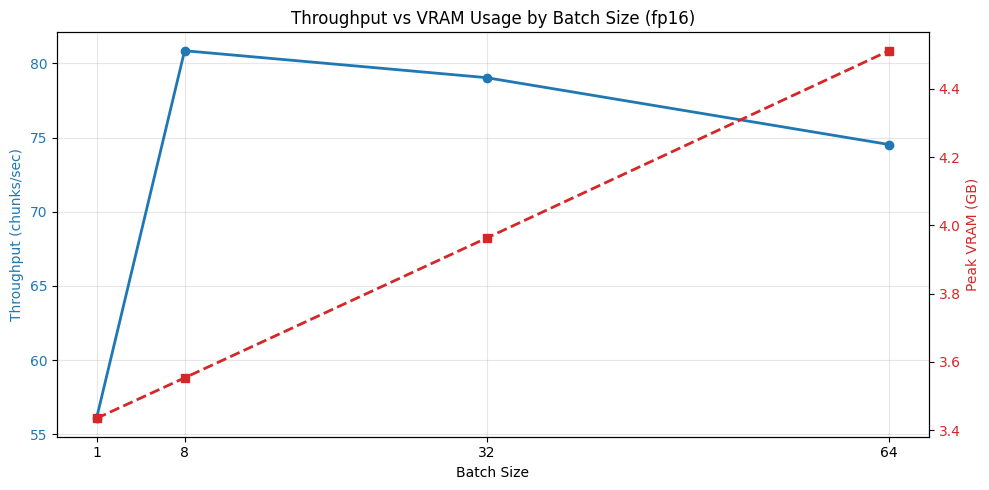

In [34]:
import matplotlib.pyplot as plt

# 이미 측정한 fp16 결과를 그래프에 사용한다.
fp16 = benchmark[benchmark["정밀도"] == "fp16"]
throughputs = fp16["청크/초"].tolist()
vrams = fp16["최대VRAM(GB)"].tolist()

# 그래프 시각화
fig, ax1 = plt.subplots(figsize=(10, 5))

# 좌측 Y축 (처리량)
color = 'tab:blue'
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Throughput (chunks/sec)', color=color)
ax1.plot(batch_sizes, throughputs, marker='o', color=color, linewidth=2, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(batch_sizes)
ax1.grid(True, alpha=0.3)

# 우측 Y축 (VRAM 사용량)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Peak VRAM (GB)', color=color)
ax2.plot(batch_sizes, vrams, marker='s', color=color, linestyle='--', linewidth=2, label='VRAM')
ax2.tick_params(axis='y', labelcolor=color)

# 제목 및 레이아웃
plt.title('Throughput vs VRAM Usage by Batch Size (fp16)')
fig.tight_layout()
plt.show()

In [35]:
import gc

del st_model
gc.collect()
torch.cuda.empty_cache()
print("측정용 모델 정리 완료. 검색용 bge_embeddings는 유지합니다.")

측정용 모델 정리 완료. 검색용 bge_embeddings는 유지합니다.


## Step 9. 로컬 LLM과 RAG 답변
예제의 `tokenizer`, `model`, `generate()`, `rag_answer()`를 사용한다.
이전에 CPU 배치로 느려졌던 문제를 막기 위해 Qwen을 GPU에 명시적으로 올린다.
답변 비교는 동일한 질문과 프롬프트로 수행한다. 검색 점수와 답변 정확도는 별도로 본다.

In [36]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# 4bit 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",                  # 4bit 표현 방식
    bnb_4bit_compute_dtype=torch.float16,       # 계산 정밀도. T4는 fp16 (bf16 미지원)
    bnb_4bit_use_double_quant=True,             # 양자화 상수를 한 번 더 양자화해 메모리 절약
)

if "model" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map={"": 0},
        dtype=torch.float16,      # 양자화되지 않는 계층(임베딩 등)의 정밀도. T4는 bf16 미지원이라 fp16을 명시합니다
    )
model.eval()

print(f"모델 로드 완료. VRAM 사용량 : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("Qwen 모델 배치:", model.hf_device_map)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

모델 로드 완료. VRAM 사용량 : 7.84 GB
Qwen 모델 배치: {'': 0}


In [37]:
def generate(system_prompt: str, user_prompt: str, max_new_tokens: int = 192) -> str:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,         # input_ids 와 attention_mask 를 함께 받습니다
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    return tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

In [38]:
SYSTEM_PROMPT = """당신은 따릉이 이용 안내 챗봇입니다.
아래 규칙을 지키세요.
1. 제공된 문서 내용에 근거해서만 답변합니다.
2. 답변 끝에 근거 항목을 표기합니다.
3. 문서에 없는 내용이면 "문서에서 확인되지 않습니다"라고 답합니다.
4. 답변은 반드시 한국어로 작성합니다. 절대 중국어를 사용하지 않습니다."""


def rag_answer(query: str, top_k: int = 3) -> str:
    contexts = retrieve(query, top_k)

    context_text = "\n\n".join(
        f"[{c['항목']}]\n{c['내용']}" for c in contexts
    )
    user_prompt = f"""다음은 따릉이 안내 문서에서 검색된 내용입니다.

{context_text}

질문 : {query}"""

    return generate(SYSTEM_PROMPT, user_prompt)

In [39]:
def hybrid_retrieve(query, top_k=3):
    # 앞서 만든 hybrid_rank로 상위 문서의 인덱스를 가져옵니다.
    top_indices = hybrid_rank(query, top_n=top_k)

    results = []
    for rank, idx in enumerate(top_indices):
        chunk = chunks[idx]
        results.append({
            "항목": chunk.metadata.get("항목", ""),
            "내용": chunk.page_content,
            "순위": rank + 1
        })
    return results

def hybrid_rag_answer(query: str, top_k: int = 3) -> str:
    contexts = hybrid_retrieve(query, top_k)

    context_text = "\n\n".join(
        f"[{c['항목']}]\n{c['내용']}" for c in contexts
    )
    user_prompt = f"다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n{context_text}\n\n질문 : {query}"

    return generate(SYSTEM_PROMPT, user_prompt)

def parent_rag_answer(query, child_top_k=6):
    parents = retrieve_parent(
        query,
        child_top_k=child_top_k,
        max_parents=3,
    )

    context_text = "\n\n".join(
        f"[{p['항목']}]\n{p['parent_text']}"
        for p in parents
    )

    user_prompt = (
        f"다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n"
        f"{context_text}\n\n질문 : {query}"
    )

    return generate(SYSTEM_PROMPT, user_prompt)

In [40]:
comparison_questions = [('횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?', '횡단보도에서는 끌고 가며, 자전거횡단도에서는 탑승한 채 건널 수 있다.'), ('7일권에서 1시간 이용권과 2시간 이용권 가격은 각각 얼마야?', '각각 3,000원과 4,000원이다.')]

for question, expected in comparison_questions:
    print(f"\n질문: {question}")
    print("[기준선]", rag_answer(question))
    print("[하이브리드]", hybrid_rag_answer(question))
    print("[부모–자식]", parent_rag_answer(question))
    print("[문서에서 확인할 내용]", expected)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



질문: 횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?
[기준선] 문서에서 확인되지 않습니다.

이용 안내 문서에서는 횡단보도를 건너는 방법이나 자전거가 건너는 곳에 대한 정보가 명시되어 있지 않습니다. 따라서 자전거를 계속 타고 횡단보도를 건너는 것이 가능한지, 혹은 따로 자전거가 건너는 곳이 있는지에 대해서는 문서에 근거해서 판단할 수 없습니다.
[하이브리드] 문서에서 확인되지 않습니다.

이용 안내 문서에서는 횡단보도를 건너는 방법이나 자전거가 건너는 곳에 대한 정보가 명시되어 있지 않습니다. 따라서 자전거를 계속 타고 횡단보도를 건너는 것이 가능한지, 혹은 따로 자전거가 건너는 곳이 있는지에 대해서는 문서에 근거해서 판단할 수 없습니다.
[부모–자식] 문서에서 확인되지 않습니다.

따르면, 문서에는 횡단보도를 건널 때 자전거를 계속 타는 것이 금지되거나 허용되는지에 대한 명시적인 언급이 없습니다. 다만, 제16조의2에서 보도, 자전거도로, 도로 우측 가장자리에서 통행하도록 지도해야 한다는 내용이 있지만, 이는 일반적인 자전거 운행 규칙에 관한 것으로, 특정 교통 시설물이나 장소에 대한 구체적인 지침은 포함되어 있지 않습니다. 따라서, 횡단보도를 건너는 경우 자전거를 계속 타는 것이 가능하지만, 이를 위한 별도의 시설이 있는지 여부는 문서에서 확인할 수 없습니다.
[문서에서 확인할 내용] 횡단보도에서는 끌고 가며, 자전거횡단도에서는 탑승한 채 건널 수 있다.

질문: 7일권에서 1시간 이용권과 2시간 이용권 가격은 각각 얼마야?
[기준선] 문서에서 확인되지 않습니다.
[하이브리드] 문서에서 확인되지 않습니다.
[부모–자식] 문서에서 확인되지 않습니다.
[문서에서 확인할 내용] 각각 3,000원과 4,000원이다.


## Step 10. 오프라인 실행 확인
예제처럼 `HF_HUB_OFFLINE=1`을 설정하고 전체 RAG를 다시 호출한다.
이미 모델이 올라온 세션에서 새 질문의 임베딩·Qdrant 검색·답변 생성을 확인하는 범위이다.
환경변수 설정은 운영체제 전체의 네트워크 차단과 다르며, 모델을 처음 받는 단계는 포함하지 않는다.
아래 셀이 오류 없이 끝나고 답변을 출력하는지 확인한 뒤 그 출력을 제출한다.

In [41]:
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
print("HF_HUB_OFFLINE =", os.environ["HF_HUB_OFFLINE"])
print("TRANSFORMERS_OFFLINE =", os.environ["TRANSFORMERS_OFFLINE"])

print(rag_answer("365일권의 1시간 이용권과 2시간 이용권은 각각 얼마야?"))
print("오프라인 환경변수 설정 후 RAG 실행 완료")

HF_HUB_OFFLINE = 1
TRANSFORMERS_OFFLINE = 1
문서에서 확인되지 않습니다.
오프라인 환경변수 설정 후 RAG 실행 완료


## Step 11. 실험 결과와 해석
표는 실제 실행값으로 만들어진다. 아래에서 기준선보다 좋아지지 않은 시도를 확인하고,
질문별 검색 결과와 문서를 근거로 해석을 작성한다.

In [42]:
display(summary)
no_gain = summary.iloc[1:][summary.iloc[1:]["기준선 대비 (%p)"] <= 0]

print("효과가 없었거나 오히려 나빠진 시도")
if no_gain.empty:
    print("아직 관찰되지 않았습니다. 이 과제 항목을 채우려면 추가 비교가 필요합니다.")
else:
    display(no_gain)
    # 개선이 없었던 첫 번째 방식의 질문별 결과를 보여준다.
    name = no_gain.iloc[0]["변경 내용"]
    display(details[details["방식"].isin(["기준선: 밀집 검색", name])])

report = "# 따릉이 로컬 RAG 실험 결과\n\n" + summary.to_markdown(index=False)
report += "\n\n## 효과가 없었거나 오히려 나빠진 시도\n\n"
report += no_gain.to_markdown(index=False) if not no_gain.empty else "아직 관찰되지 않음. 추가 실험 필요."
report += "\n\n## 왜 그런 결과가 나왔는지에 대한 해석\n\n"
report += "아래 노트북의 해석 칸에 실제 질문·검색 결과·원문을 대조하여 작성한다."
with open("bikeseoul_rag_results/experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report)

,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
0,기준선: 밀집 검색,95.0,0.0,100.0,90.0
1,BM25 단독,85.0,-10.0,90.0,80.0
2,트랙2: RRF 1:1,95.0,0.0,90.0,100.0
3,트랙2: RRF 0.3:0.7,95.0,0.0,90.0,100.0
4,트랙4: 자식3→부모3,100.0,5.0,100.0,100.0
5,트랙4: 자식6→부모3,100.0,5.0,100.0,100.0
6,트랙4: 자식12→부모3,100.0,5.0,100.0,100.0


효과가 없었거나 오히려 나빠진 시도


,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
1,BM25 단독,85.0,-10.0,90.0,80.0
2,트랙2: RRF 1:1,95.0,0.0,90.0,100.0
3,트랙2: RRF 0.3:0.7,95.0,0.0,90.0,100.0


,방식,질문,정답,검색 결과,Hit@3,반환 부모 수
0,기준선: 밀집 검색,가입할 때 입력한 정보가 바뀌면 어떻게 해야 해?,제5조 (회원신청),"[제5조 (회원신청), 제12조 회원자격 정지·해지 및 서비스 이용제한, 제13조 ...",1,3
1,기준선: 밀집 검색,열세 살 이하인 아이가 이용할 수 있는 예외는 뭐야?,제9조 서비스 이용 시 주의사항,"[제9조 서비스 이용 시 주의사항, 제16조 이용자의 의무와 책임 — 제10항 제1...",1,3
2,기준선: 밀집 검색,반납하고 다시 빌리는 식으로 하루 동안 여러 번 이용할 수 있어?,제10조 서비스 이용시간,"[제10조 서비스 이용시간, 제14조 추가요금, 제13조 기본요금 환불 및 결제 취소]",1,3
3,기준선: 밀집 검색,이용 시간을 넘기면 어떤 결제수단으로 추가요금이 청구돼?,제11조 서비스 이용요금,"[제14조 추가요금, 제11조 서비스 이용요금, 제10조 서비스 이용시간]",1,3
4,기준선: 밀집 검색,고의로 시설물을 두 번 훼손하면 얼마나 이용이 제한돼?,제12조 회원자격 정지·해지 및 서비스 이용제한,"[제10조 서비스 이용시간, 제12조 회원자격 정지·해지 및 서비스 이용제한, 제1...",1,3
5,기준선: 밀집 검색,한 번도 쓰지 않은 이용권이 결제 후 일 년이 지나면 어떻게 처리돼?,제13조 기본요금 환불 및 결제 취소,"[제13조 기본요금 환불 및 결제 취소, 제12조 회원자격 정지·해지 및 서비스 이...",1,3
6,기준선: 밀집 검색,내가 원해서 탈퇴하며 환불받을 때 결제 수수료는 누가 내?,제13조 기본요금 환불 및 결제 취소,"[제13조 기본요금 환불 및 결제 취소, 제12조 회원자격 정지·해지 및 서비스 이...",1,3
7,기준선: 밀집 검색,시간을 초과했을 때 추가요금은 얼마씩 붙고 최대 얼마까지 내?,제14조 추가요금,"[제14조 추가요금, 제10조 서비스 이용시간, 제11조 서비스 이용요금]",1,3
8,기준선: 밀집 검색,가족권으로 어린아이가 탈 때 보호자가 미리 확인해야 할 사항은?,제16조 이용자의 의무와 책임 — 제10항 제11호 발췌,"[제16조 이용자의 의무와 책임 — 제10항 제11호 발췌, 제9조 서비스 이용 시...",1,3
9,기준선: 밀집 검색,자전거 결함으로 사고가 나면 증빙자료는 누가 모아야 해?,제18조 이의신청 및 손해배상,"[제18조 이의신청 및 손해배상, 제16조 이용자의 의무와 책임 — 제10항 제11...",1,3


In [43]:

import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi

# 트랙 2+4: 자식 문장에 대한 BM25 검색 준비
scenario_child_bm25 = BM25Okapi(
    [tokenize_ko(child["text"]) for child in children]
)

def scenario_hybrid_parent_retrieve(
    query, candidate_k=20, child_top_k=6, max_parents=3
):
    dense_hits = client.query_points(
        collection_name=CHILD_COLLECTION,
        query=bge_embeddings.embed_query(query),
        limit=candidate_k,
    ).points
    dense_ids = [int(hit.id) for hit in dense_hits]

    bm25_scores = scenario_child_bm25.get_scores(tokenize_ko(query))
    bm25_ids = [
        int(idx)
        for idx in np.argsort(bm25_scores)[::-1][:candidate_k]
    ]

    child_ids = rrf(
        [dense_ids, bm25_ids],
        k=60,
        top_n=child_top_k,
    )

    contexts = []
    seen = set()

    for child_id in child_ids:
        child = children[child_id]
        parent_id = child["parent_id"]

        if parent_id in seen:
            continue

        seen.add(parent_id)
        contexts.append({
            "항목": child["항목"],
            "내용": child["parent_text"],
        })

        if len(contexts) >= max_parents:
            break

    return contexts


def scenario_parent_retrieve(query):
    parents = retrieve_parent(
        query,
        child_top_k=6,
        max_parents=3,
    )
    return [
        {"항목": p["항목"], "내용": p["parent_text"]}
        for p in parents
    ]


scenario_methods = [
    ("기준선: 밀집 검색", lambda q: retrieve(q, top_k=3)),
    (
        "트랙 2: 하이브리드 RRF 1:1",
        lambda q: hybrid_retrieve(q, top_k=3),
    ),
    ("트랙 4: 부모–자식 검색", scenario_parent_retrieve),
    (
        "트랙 2+4: 하이브리드 부모–자식 검색",
        scenario_hybrid_parent_retrieve,
    ),
]

scenario_questions = [
    "1시간 이용권으로 오전에 40분 타고 반납했어. "
    "오후에 다시 빌려도 돼? 하루에 몇 번까지 탈 수 있어?",

    "365일권을 사려고 하는데, 1시간짜리와 2시간짜리는 "
    "각각 얼마야? 2시간짜리를 고르면 얼마 더 내?",

    "회원가입 없이 오늘만 두 시간 정도 타고 싶어. "
    "어떤 이용권을 살 수 있고 가격은 얼마야?",

    "자전거 타다가 횡단보도가 나왔어. "
    "옆에 자전거횡단도도 있으면 어디로 어떻게 건너야 해?",

    "자전거를 잠갔는데 반납 알림이 안 와. 그냥 가도 돼? "
    "앱에서 어떤 버튼을 눌러야 해결돼?",

    "지금 강남역 근처에서 바로 빌릴 수 있는 따릉이는 몇 대야? "
    "가장 가까운 대여소도 알려줘.",
]

scenario_results = []

for question_no, question in enumerate(scenario_questions, start=1):
    print("\n" + "=" * 80)
    print(f"질문 {question_no}/{len(scenario_questions)}")
    print(question, flush=True)

    for method_name, retrieve_fn in scenario_methods:
        print(f"\n[{method_name}]", flush=True)

        contexts = retrieve_fn(question)
        titles = [c["항목"] for c in contexts]
        print("검색 항목:", " / ".join(titles), flush=True)

        context_text = "\n\n".join(
            f"[{c['항목']}]\n{c['내용']}"
            for c in contexts
        )
        user_prompt = (
            "다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n"
            f"{context_text}\n\n질문 : {question}"
        )

        answer = generate(SYSTEM_PROMPT, user_prompt)
        print("답변:", answer, flush=True)

        scenario_results.append({
            "질문 번호": question_no,
            "질문": question,
            "방식": method_name,
            "검색 항목": " / ".join(titles),
            "전달 근거": context_text,
            "답변": answer,
        })

scenario_results_df = pd.DataFrame(scenario_results)
print(f"\n완료: 답변 {len(scenario_results_df)}개")


질문 1/6
1시간 이용권으로 오전에 40분 타고 반납했어. 오후에 다시 빌려도 돼? 하루에 몇 번까지 탈 수 있어?

[기준선: 밀집 검색]
검색 항목: 제10조 서비스 이용시간 / 제14조 추가요금 / 제13조 기본요금 환불 및 결제 취소
답변: 네, 오전에 40분 이용 후 반납하면 남은 20분 이용권이 남아 있습니다. 이 이용권은 오후에 다시 이용하실 수 있습니다. 하루 내에 이용 가능한 횟수는 제한이 없습니다. 일일권 기준으로 대여 개시부터 24시간까지 이용할 수 있으므로, 하루 동안 여러 차례 이용하실 수 있습니다.

근거: 
- 제10조 서비스 이용시간 (①)

[트랙 2: 하이브리드 RRF 1:1]
검색 항목: 제10조 서비스 이용시간 / 제14조 추가요금 / 제12조 회원자격 정지·해지 및 서비스 이용제한
답변: 네, 오전에 40분 이용 후 오후에 다시 빌릴 수 있습니다. 1시간 이용권의 기본 이용 시간은 60분이며, 회당 60분 이내 반납 시 반복 대여가 가능합니다. 따라서 일일권 기준으로 대여 개시부터 24시간까지 이용할 수 있으므로, 하루에 여러 번 이용할 수 있습니다.

근거: [제10조 서비스 이용시간]

[트랙 4: 부모–자식 검색]
검색 항목: 제10조 서비스 이용시간 / 제14조 추가요금
답변: 네, 오전에 40분 이용 후 반납하면 오후에 다시 대여할 수 있습니다. 1시간 이용권의 기본 이용 시간은 60분이며, 60분 이내 반납 시 반복 대여가 가능합니다. 또한, 일일권 기준으로 대여 개시부터 24시간까지 이용할 수 있으므로 하루 내에서 여러 번 대여하고 반납할 수 있습니다. 

근거: [제10조 서비스 이용시간]

[트랙 2+4: 하이브리드 부모–자식 검색]
검색 항목: 제10조 서비스 이용시간 / 제14조 추가요금 / 제12조 회원자격 정지·해지 및 서비스 이용제한
답변: 네, 오전에 40분 이용 후 오후에 다시 빌릴 수 있습니다. 1시간 이용권의 기본 이용 시간은 60분이며, 회당 60분 이내 반납 시 반복 대여가 가능합니다

## 실험 결과와 해석
기준선 Hit@3는 95%, 부모–자식 검색은 100%로 5%p 개선됐습니다. 하이브리드는 질문 유형별 성능이 달라졌고, BM25 단독은 성능이 떨어졌습니다. 아래는 새 실행 결과를 기준으로 작성한 평가문입니다.

1. 실험 구성과 청킹 전략

따릉이 이용약관 발췌문을 사용해 BGE-M3 임베딩, Qdrant 검색, Qwen2.5-7B-Instruct 답변 생성으로 로컬 RAG를 구성했다. 평가 질문은 의미 질문 10개와 조항 번호를 포함한 식별자 질문 10개로 구성했다.

약관은 하나의 조항 안에 적용 조건과 예외가 함께 들어 있으므로, Markdown 제목을 기준으로 조항 전체를 하나의 청크로 만들었다. 부모–자식 청킹에서는 조항을 줄 단위로 나누어 검색하고, 답변을 생성할 때는 해당 조항 전체를 전달했다.

현재 저장된 실행에서는 약관 조항 9개와 중복 입력된 파일 저장 명령 1개가 포함되어 부모 청크 10개, 자식 청크 58개가 생성됐다. 아래 수치는 이 실행 상태에서 측정한 결과다.

2. 검색 성능 비교

Hit@3는 검색한 상위 3개 청크 안에 정답 조항이 포함된 질문의 비율이다.

| 변경 내용 | 전체 Hit@3 | 기준선 대비 | 의미 질문 | 식별자 질문 |
| --- | --- | --- | --- | --- |
| 기준선: 밀집 검색 | 95% | — | 100% | 90% |
| BM25 단독 | 85% | −10%p | 90% | 80% |
| 하이브리드 RRF 1:1 | 95% | 0%p | 90% | 100% |
| 하이브리드 RRF 0.3:0.7 | 95% | 0%p | 90% | 100% |
| 자식 3개 → 부모 최대 3개 | 100% | +5%p | 100% | 100% |
| 자식 6개 → 부모 최대 3개 | 100% | +5%p | 100% | 100% |
| 자식 12개 → 부모 최대 3개 | 100% | +5%p | 100% | 100% |

3. 개선 효과가 있었던 시도

부모–자식 검색은 기준선의 19문항 성공에서 20문항 성공으로 개선됐다.

기준선이 놓친 질문은 “제13조 제2항에서 정한 이용권의 대여 개시 유효기간은?”이었다. 기준선은 제10조 서비스 이용시간 등을 검색했지만, 정답인 제13조를 상위 3개에 포함하지 못했다. 부모–자식 검색에서는 이 질문도 성공했다.

이용권의 대여 개시 유효기간과 한 번 빌렸을 때의 기본 이용시간은 표현이 비슷하지만 서로 다른 개념이다. 조항 전체를 임베딩하면 여러 내용이 함께 반영되는 반면, 자식 청크에서는 유효기간을 설명하는 문장이 직접 검색 대상이 된다. 이번 개선에는 이러한 검색 단위의 차이가 영향을 주었을 가능성이 있다.

자식 후보를 3개에서 6개, 12개로 늘려도 점수는 같았다. 이번 평가에서는 후보 3개로도 모든 정답 조항을 찾았으므로, 후보 확대에 따른 추가 효과는 관찰되지 않았다.

4. 효과가 없었거나 나빠진 시도

BM25 단독 검색은 85%로 기준선보다 10%p 낮았다. 예를 들어 “가입할 때 입력한 정보가 바뀌면 어떻게 해야 해?”라는 질문에서 정답인 제5조를 찾지 못했다.

질문에는 “정보가 바뀌면”이라는 표현이 있지만, 문서에는 “변경사항 발생 시 지체없이 갱신”이라는 표현이 사용된다. 이러한 표현 차이는 단어 일치에 의존하는 BM25에 불리하게 작용했을 가능성이 있다.

식별자 질문에서도 BM25가 항상 유리하지 않았다. 현재 토큰화 코드는 제13조를 제, 13, 조로 나눈다. 조항 번호와 본문에 등장하는 나이·시간·항목 번호를 구별하기 어려운 구조이므로, 조항 식별자를 하나의 토큰으로 보존하는 개선을 검토할 수 있다. 다만 이 개선은 이번 실행에서 측정하지 않았다.

하이브리드 검색은 식별자 질문을 90%에서 100%로 개선했지만, 의미 질문은 100%에서 90%로 낮아졌다. 두 변화가 상쇄되어 전체 점수는 95%로 유지됐다. 따라서 전체 점수가 같더라도 검색 특성에는 변화가 있었다.

BM25 가중치를 높인 RRF 0.3:0.7도 전체·유형별 점수가 동일했다. 이번 평가에서는 가중치 조정에 따른 추가 이득이 확인되지 않았다.

5. 배치 크기와 정밀도 실험

배치 크기 8에서 FP32는 58.55초, FP16은 12.37초가 걸렸다. 같은 1,000개 입력을 처리하는 시간이 약 4.73배 차이 났으며, 측정된 최대 GPU 메모리는 4.82GB에서 3.55GB로 줄었다.

FP16의 처리량은 배치 8에서 약 81청크/초로 가장 높았다. 배치 32에서는 79청크/초, 배치 64에서는 75청크/초로 낮아져, 배치를 크게 만드는 것이 항상 유리하지는 않았다. 다만 각 설정을 한 번씩 측정했으므로 작은 속도 차이에는 측정 변동이 포함될 수 있다.

이 실험은 같은 문서를 반복해 만든 입력을 사용했으며, 최대 메모리에는 검색용 임베딩 모델도 포함된다. 또한 별도 측정용 모델의 정밀도를 변경했으므로, 이 결과는 검색 Hit@3 개선의 근거와 구분해서 해석해야 한다.

6. 생성 답변 평가

검색 점수가 높아져도 답변의 정확성이 자동으로 보장되지는 않았다.

| 질문 사례 | 실제 출력에서 확인한 점 |
| --- | --- |
| 40분 이용 후 재대여 | 기준선은 올바른 제10조를 검색했지만 “남은 20분 이용권”이라는 잘못된 해석을 생성했다. 하이브리드와 부모–자식 답변은 회당 이용시간과 반복 대여 조건을 설명했다. |
| 365일권 가격 | 모든 방식이 문서에서 확인되지 않는다고 답했다. 새 발췌문에 가격표가 없으므로 적절한 응답이었다. |
| 비회원 이용권 | 가격은 확인되지 않는다고 답하면서도, 문서에 없는 비회원 구매 조건을 단정하는 답변이 나왔다. |
| 횡단보도 통행 | 발췌문에 구체적인 근거가 없는데도 통행 방법을 추론했다. 결합 방식에서는 중국어와 가짜 대화문도 출력됐다. |
| 반납 알림과 앱 버튼 | 기준선과 결합 방식에서 문서에 없는 버튼 이름을 생성했다. 부모–자식 방식은 해당 정보를 제공할 수 없다고 답했다. |
| 실시간 대여 가능 대수 | 모든 방식이 실제 대수와 대여소 위치를 만들어내지 않고 정보 부족을 알렸다. |

이 결과는 정답 조항의 검색 여부와 답변의 근거 충실도를 별도로 평가해야 함을 보여준다. 특히 일부만 답할 수 있는 질문에서는, 확인 가능한 내용과 확인되지 않는 내용을 나누어 답하도록 개선할 필요가 있다.